In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import kagglehub
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

In [12]:
path = kagglehub.dataset_download("shivachandel/kc-house-data")
print(os.listdir(path))

['kc_house_data.csv']


In [17]:
csv_path = os.path.join(path, "kc_house_data.csv")
df = pd.read_csv(csv_path)
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


In [18]:
df.drop('id', axis=1, inplace=True)
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       2
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [19]:
df['sqft_above'] = df['sqft_above'].fillna(df['sqft_above'].median())

<Axes: xlabel='waterfront', ylabel='price'>

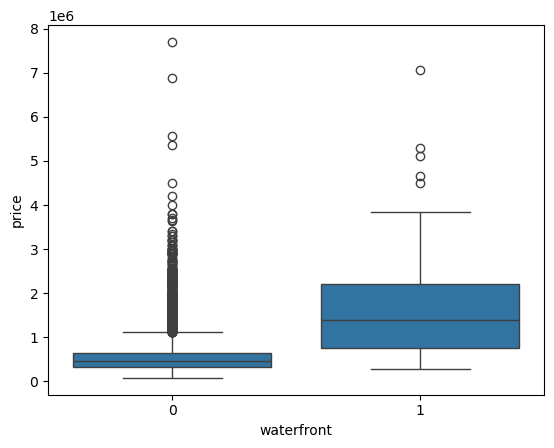

In [20]:
sns.boxplot(x='waterfront',y='price', data=df)

The boxplot shows that houses with a waterfront view (1) have a higher median price than those without a waterfront view (0). The price distribution for waterfront houses is also more spread out, indicating greater variability. This suggests that waterfront location is associated with higher house prices.

In [23]:
df_num = df.select_dtypes(include=[np.number])
df_num.corr()['price'].sort_values()

zipcode         -0.053203
long             0.021626
condition        0.036362
yr_built         0.054012
sqft_lot15       0.082447
sqft_lot         0.089661
yr_renovated     0.126434
floors           0.256794
waterfront       0.266369
lat              0.307003
bedrooms         0.308350
sqft_basement    0.323816
view             0.397293
bathrooms        0.525138
sqft_living15    0.585379
sqft_above       0.605561
grade            0.667434
sqft_living      0.702035
price            1.000000
Name: price, dtype: float64

(0.0, 8084027.521615034)

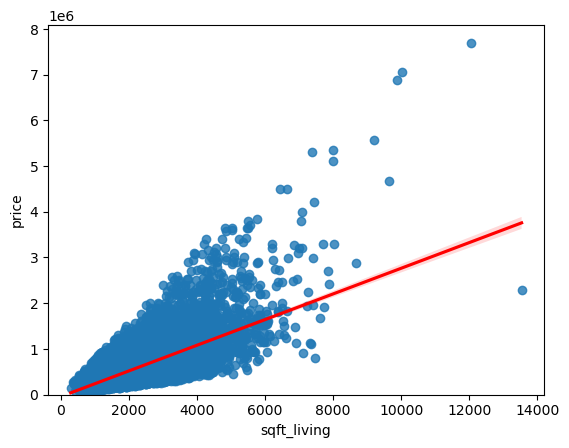

In [33]:
sns.regplot(x='sqft_living',y='price',data=df, line_kws={'color':'r'})
plt.ylim(0,)

The plot shows a positive correlation between sqft_living and price, meaning that houses with larger living areas generally have higher prices. However, the wide spread of points indicates that other factors also influence house prices.

# Model Development

In [25]:
X = df[['sqft_living']]
Y = df['price']
lm = LinearRegression()
lm.fit(X,Y)
print("R^2:", lm.score(X, Y))

R^2: 0.4928532179037931


An $R^2$ of **0.493** means that `sqft_living` explains about **49.3%** of the variation in house prices. This suggests that living area is an important factor in predicting price, but other variables also influence house prices.

In [26]:
features =["floors", "waterfront","lat" ,"bedrooms" ,"sqft_basement" ,"view" ,"bathrooms","sqft_living15","sqft_above","grade","sqft_living"] 
Z = df[features]
lm.fit(Z,Y)
print("R^2:", lm.score(Z, Y))

R^2: 0.6577308741398071


An $R^2$ of **0.658** means that the multiple regression model explains about **65.8%** of the variation in house prices. This is higher than the model using only `sqft_living`, so using multiple features improves the model’s ability to predict price.

In [28]:
Input=[('scale',StandardScaler()),
       ('polynomial', PolynomialFeatures(include_bias=False)),
       ('model',LinearRegression())]

pipe = Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe = pipe.predict(Z)
print('R^2:', r2_score(Y, ypipe))

R^2: 0.7513499950058858


An $R^2$ of **0.751** means that the pipeline model explains about **75.1%** of the variation in house prices. This is higher than the simple and multiple linear regression models, which suggests that the pipeline captures the relationship between the features and price more effectively.

The pipeline model performs better than the simple and multiple linear regression models because it achieves the highest $R^2$ value. This suggests that scaling the features and adding polynomial terms helps the model capture more complex relationships between the predictors and house price. However, since the score is measured on the training data, further evaluation on test data would be needed to confirm whether it generalizes well.

# Model Evaluation

In [34]:
X = df[features]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)
print("number of test samples:", x_test.shape[0])
print("number of training samples:",x_train.shape[0])

number of test samples: 3242
number of training samples: 18371


In [39]:
lm.fit(x_train, y_train)
yhat_lm = lm.predict(x_test)
print('R^2:', r2_score(y_test, yhat_lm))

R^2: 0.6480466593646571


In [37]:
pipe.fit(x_train, y_train)
yhat_pipe = pipe.predict(x_test)
print('R^2:', r2_score(y_test, yhat_pipe))

R^2: 0.7119749990756628


In [38]:
RidgeModel = Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat_ridge = RidgeModel.predict(x_test)
print('R^2:', r2_score(y_test, yhat_ridge))

R^2: 0.6480391797944001


Based on the test $R^2$ values, the pipeline model performs better than Ridge regression. The pipeline achieves an $R^2$ of **0.712**, while Multiple Linear Regression and Ridge regression gives **0.648**, so the pipeline explains more variation in house prices on the test set.

In [40]:
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)

In [41]:
lm.fit(x_train_pr, y_train)
yhat_lm_pr = lm.predict(x_test_pr)
print('R^2:', r2_score(y_test, yhat_lm_pr))

R^2: 0.7119749474936443


In [44]:
RidgeModel.fit(x_train_pr, y_train)
yhat_ridge_pr = RidgeModel.predict(x_test_pr)
print('R^2:', r2_score(y_test, yhat_ridge_pr))

R^2: 0.7004334877245724


Among the models tested, the pipeline model achieved the highest test $R^2$, but its performance was almost the same as the polynomial linear regression model. This indicates that adding polynomial features helps improve prediction accuracy by capturing more complex relationships between the predictors and house price. In contrast, polynomial Ridge regression produced a slightly lower $R^2$, suggesting that regularization did not improve performance for this dataset. Overall, the results show that models with polynomial features perform better than the basic regression models, and the pipeline provides the best overall fit on the test data.